In [7]:
import numpy as np
import scipy as scipy
import scipy.special
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib import colors
import time
import uncertainties as error
import pandas as pd
np.random.seed(12345) #pi seed for pi finding

Problem 1a.)

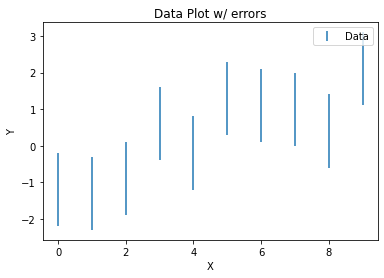

In [8]:
#This is my data input for the .txt files, may need to adjust the filepath
Data=pd.read_csv('HW5_Data/data_HW5.txt', names=['x', 'y', 'yerr'], delimiter=' ')

plt.errorbar(Data['x'], Data['y'], yerr=Data['yerr'], label='Data', linestyle='')
plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Data Plot w/ errors')
plt.show()

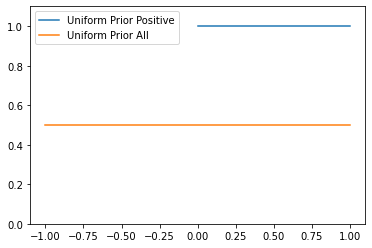

1.0
1.0


In [9]:
#We'll do an analysis assuming some uniform priors.
density = 1001
mtestPositive = np.linspace(0, 1, density)
mtestAll = np.linspace(-1, 1, density)

def UniformPrior(minimum, maximum, density):
    return(np.zeros(density) + 1/(maximum-minimum))

plt.plot(mtestPositive, UniformPrior(0, 1, density), label='Uniform Prior Positive')
plt.plot(mtestAll, UniformPrior(-1, 1, density), label='Uniform Prior All')
plt.ylim(0, 1.1)
plt.legend()
plt.show()
#This just shows that I did make the uniform prior correctly. And we can verify with...
print(np.trapz(UniformPrior(0, 1, density), x=mtestPositive))
print(np.trapz(UniformPrior(-1, 1, density), x=mtestAll))
#both these print statements are 1 which is what we want

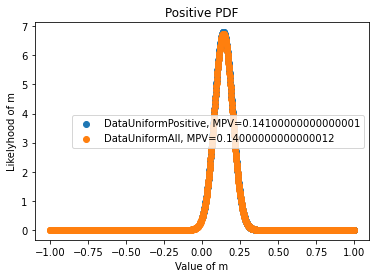

In [10]:
#OK now we have our prior, we need to have a likelyhood function 
#Copying some code from HW4
def PDataGivenParam(Data, m, Prior):
    temp=[]
    for i in range(len(Data['y'])):
        temp.append(1/(np.sqrt(2*np.pi)*Data['yerr'][i]) * 
                    np.exp(-(Data['y'][i]-m*Data['x'][i])**2/(2*Data['yerr'][i]**2)))
    Likelyhood = np.product(temp) #this might not be normalized right according to past me...
    Posterior = Likelyhood * Prior
    return(Posterior)

DataUniformPositive = []
DataUniformAll = []
for i in range(len(mtestPositive)):
    DataUniformPositive.append(PDataGivenParam(Data, mtestPositive[i], UniformPrior(0, 1, density)[i]))
for i in range(len(mtestAll)):
    DataUniformAll.append(PDataGivenParam(Data, mtestAll[i], UniformPrior(-1, 1, density)[i]))
    
DataUniformPositive /= np.trapz(DataUniformPositive, x=mtestPositive)
DataUniformAll /= np.trapz(DataUniformAll, x=mtestAll)

plt.scatter(mtestPositive, DataUniformPositive, label='DataUniformPositive, MPV='+str(mtestPositive[np.argmax(DataUniformPositive)]))
plt.scatter(mtestAll, DataUniformAll, label='DataUniformAll, MPV='+str(mtestAll[np.argmax(DataUniformAll)]))
plt.legend()
plt.title('Positive PDF')
plt.xlabel('Value of m')
plt.ylabel('Likelyhood of m')
plt.show()

#Hmm so with large density (1001 for example) these plots look basically identical

1b.)

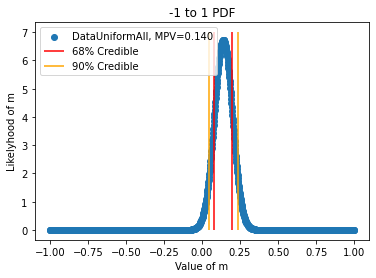

68% credible region is between (0.08200000000000007, 0.19799999999999995)
90% credible region is between (0.04400000000000004, 0.238)


In [11]:
#ok so for credible intervals I think the central interval and the HPD intervals should be like almost identical?
#But I'll make a HDP one

def HDP(x, PDF, alpha):
    dx = np.diff(x)
    dx = np.append(dx, dx[-1]) #just to make same length. And leaving general for future homeworks
    #OK so the way I'm going about this is to sort by probability
    idx = np.argsort(PDF)[::-1] #in this case first is highest likelyhood, last is least likely
    temp = []
    cumulative = 0
    for i in idx: #ok so basically we sort the pdf by decreasing probability, and scan in new values if we haven't hit alpha
        cumulative += PDF[i] * dx[i]
        temp.append(i)
        if cumulative >= alpha:
            break
    temp = np.array(temp)
    #HPD is min/max value
    HDPmin = x[temp].min()
    HDPmax = x[temp].max()
    return(HDPmin, HDPmax) #This is probably overkill but this does account for everything
#This will break on multipeaked PDFs but as long as it's smooth its good. This will handle skew

HDP_68=HDP(mtestAll, DataUniformAll, 0.68)
HDP_90=HDP(mtestAll, DataUniformAll, 0.90)

plt.scatter(mtestAll, DataUniformAll, label='DataUniformAll, MPV='+str(mtestAll[np.argmax(DataUniformAll)])[0:5])
plt.vlines(HDP_68, 0, 7, label='68% Credible', color = 'red')
plt.vlines(HDP_90, 0, 7, label='90% Credible', color = 'orange')
plt.legend()
plt.title('-1 to 1 PDF')
plt.xlabel('Value of m')
plt.ylabel('Likelyhood of m')
plt.show()

print('68% credible region is between', HDP_68)
print('90% credible region is between', HDP_90)

1c.)

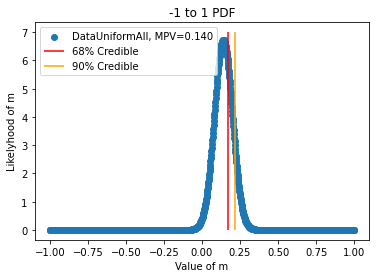

68% upper limit is  0.16799999999999993
90% upper limit is  0.21599999999999997


In [12]:
def UpperLimit(x, PDF, alpha):
    dx = np.diff(x)
    dx = np.append(dx, dx[-1]) #just to make same length. And leaving general for future homeworks
    #We DONT sort by probability here
    temp = []
    cumulative = 0
    for i in range(len(PDF)):
        cumulative += PDF[i] * dx[i]
        temp.append(i)
        if cumulative >= alpha:
            break
    temp = np.array(temp)
    UpperLimitmax = x[temp].max()
    return(UpperLimitmax)

UpperLimit_68=UpperLimit(mtestAll, DataUniformAll, 0.68)
UpperLimit_90=UpperLimit(mtestAll, DataUniformAll, 0.90)

plt.scatter(mtestAll, DataUniformAll, label='DataUniformAll, MPV='+str(mtestAll[np.argmax(DataUniformAll)])[0:5])
plt.vlines(UpperLimit_68, 0, 7, label='68% Credible', color = 'red')
plt.vlines(UpperLimit_90, 0, 7, label='90% Credible', color = 'orange')
plt.legend()
plt.title('-1 to 1 PDF')
plt.xlabel('Value of m')
plt.ylabel('Likelyhood of m')
plt.show()

print('68% upper limit is ', UpperLimit_68)
print('90% upper limit is ', UpperLimit_90)

#The upper limits should be slightly less than the upper bounds of the HDP
#This is because the upper limit is taking in CDF from the entire left side. While generally very small, this is non-zero
#Because the tails are non-zero we hit the confidence level 'sooner' as me move to the right

1d.)

Optimized slope: m= 0.14070175057297893
Best Fit Chi2: 7.167859649122811
m=0 Chi2: 12.81
deltaChi2: 5.64214035087719


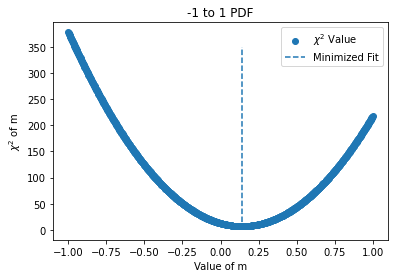

In [13]:
#Compute a chi2
def Chi2(Data, m):
    Chi2=np.sum((Data['y'] - m*Data['x'])**2 / Data['yerr']**2)
    return(Chi2)
def Chi2Minimizer(m, Data): #apparently the minimizer expects data last
    return(Chi2(Data, m))

Chi2Values=[]
for i in range(len(mtestAll)):
    Chi2Values.append(Chi2(Data, mtestAll[i]))
    
plt.scatter(mtestAll, Chi2Values, label=r'$\chi^2$ Value')
plt.title('-1 to 1 PDF')
plt.xlabel('Value of m')
plt.ylabel(r'$\chi^2$ of m')

#Now we do a minimization to find the best slope from the chi2 values
print('Optimized slope: m=', scipy.optimize.minimize(Chi2Minimizer, x0=0, args=(Data)).x[0])
plt.vlines(scipy.optimize.minimize(Chi2Minimizer, x0=0, args=(Data)).x[0], 0, 350, linestyle='--', label='Minimized Fit')
plt.legend()

#Lets find deltaChi2 between m=0 and the best fit value
BestFit = scipy.optimize.minimize(Chi2Minimizer, x0=0, args=(Data)).fun
ZeroPoint = Chi2(Data, 0)

print('Best Fit Chi2:', BestFit)
print('m=0 Chi2:', ZeroPoint)
print('deltaChi2:', ZeroPoint-BestFit)

1e.)

Expected runtime: 8.172413199965376 seconds


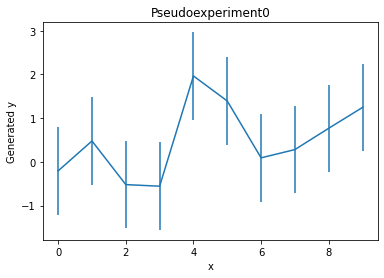

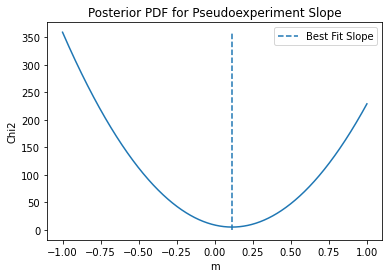

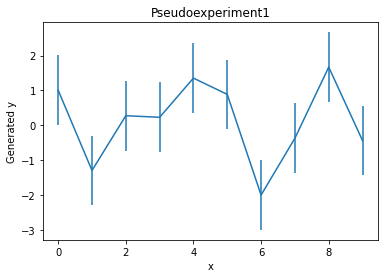

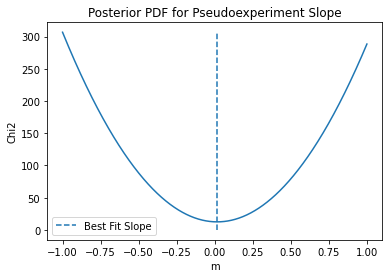

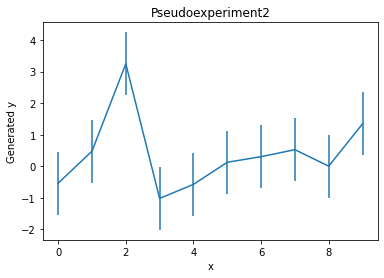

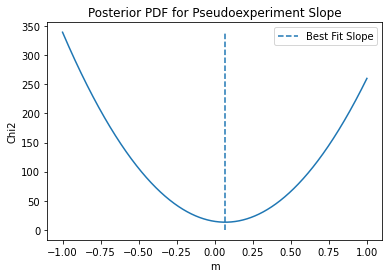

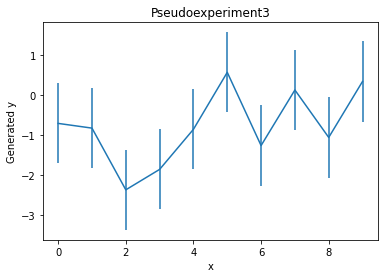

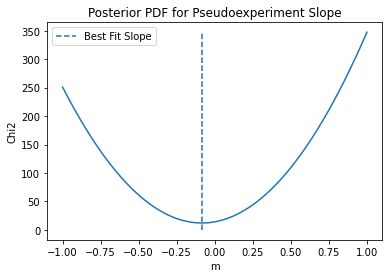

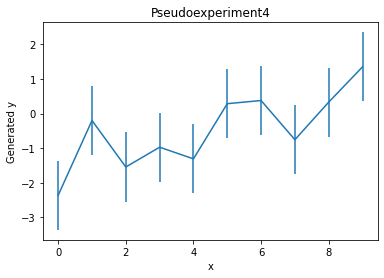

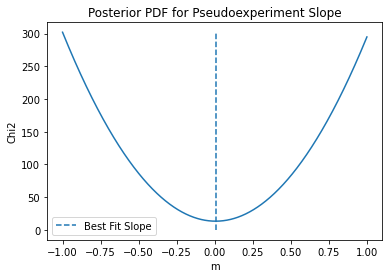

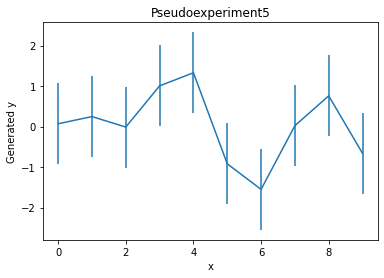

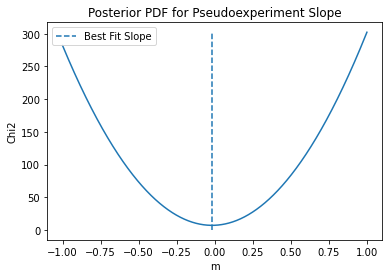

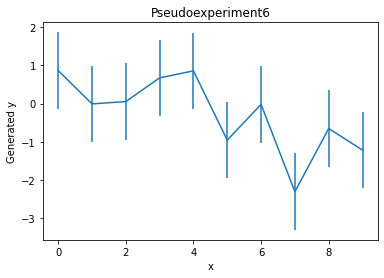

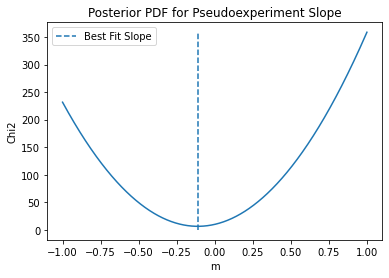

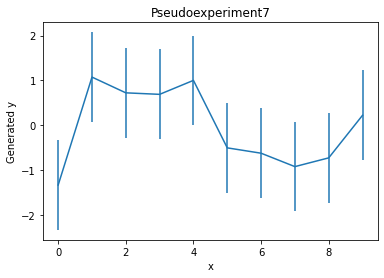

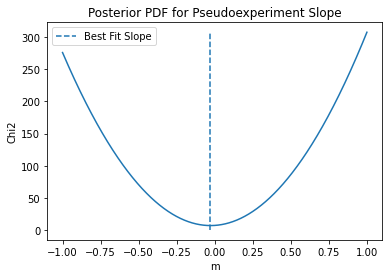

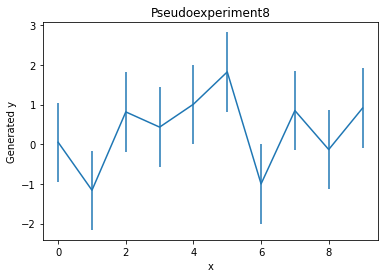

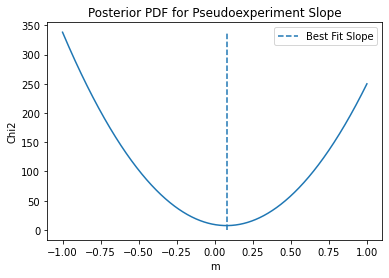

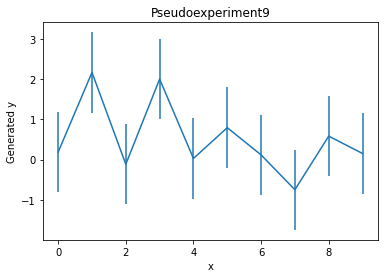

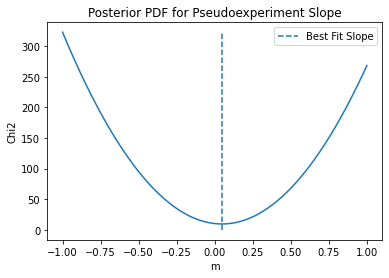

In [14]:
#Determining the 68 and 90% upper bounds for m=0 confindence with Feldman-Cousins
#First step is the 'pseudoexperiments'
x=Data['x']
def Pseudoexperiment(x, yerr=1, m=0):
    Values=x*m + np.random.normal(loc=0, scale=yerr, size=len(x)) #this should add the gaussian noise to the data
    yerrs = np.zeros(len(x)) + yerr
    return(pd.DataFrame(data=np.array([x, Values, yerrs]).T, columns = ['x', 'y', 'yerr']))


debug=True #Keep false for large N
N = 1000
BestFitSlope = []
deltaChi2 = []
# start = time.perf_counter()
print('Expected runtime:', 0.8172413199965376 * N, 'seconds')
for i in range(N): #make N experiments
    PseudoData = Pseudoexperiment(x)
    UniformPosteriors=[]
    for j in range(len(mtestAll)):
        UniformPosteriors.append(Chi2(PseudoData, mtestAll[j])) 
    BestFitSlope.append(mtestAll[np.argmin(UniformPosteriors)])#This finds the best m value for each pseudoexperiment
    if debug == True: #makes graphs if debug
        plt.errorbar(PseudoData['x'], PseudoData['y'], yerr=PseudoData['yerr'])
        plt.title('Pseudoexperiment' + str(i))
        plt.xlabel('x')
        plt.ylabel('Generated y')
        plt.show()
        plt.plot(mtestAll, UniformPosteriors)
        plt.title('Posterior PDF for Pseudoexperiment Slope')
        plt.xlabel('m')
        plt.ylabel('Chi2')
        plt.vlines(BestFitSlope[i], 0, max(UniformPosteriors), label = 'Best Fit Slope', linestyle = '--')
        plt.legend()
        plt.show()
    deltaChi2.append(Chi2(PseudoData, 0) - Chi2(PseudoData, mtestAll[np.argmin(UniformPosteriors)])) #finds deltaChi2
# end = time.perf_counter()
# runtime = end - start
# runtimePer = runtime/N
# print(runtimePer)

In [352]:
#For Feldman-Cousins we need the critical value
#This can be a ln(L), or chi2
def CriticalValue(Data, alpha = 90):
    '''
    This returns the critical value for alpha(measured as a percentile so 0-100), as well as the index of that result
    '''
    #I want this to return the value
    return(np.percentile(Data, alpha)) #oh lol thought this would be a bigger function...

CriticalValue(deltaChi2)

2.6526753881650325

In [353]:
print('The 68% confidence upper limit for the pseudoexperiments is:', CriticalValue(deltaChi2, alpha=68))
print('The 90% confidence upper limit for the pseudoexperiments is:', CriticalValue(deltaChi2, alpha=90))
print('The 99.7% confidence upper limit for the pseudoexperiments is:', CriticalValue(deltaChi2, alpha=99.7))

The 68% confidence upper limit for the pseudoexperiments is: 0.9862462929843631
The 90% confidence upper limit for the pseudoexperiments is: 2.6526753881650325
The 99.7% confidence upper limit for the pseudoexperiments is: 7.899710761639259


In [360]:
#What is the real data's slope estimator and deltaLikelyhood to m=0?
BestFitSlope = round(mtestAll[np.argmax(DataUniformAll)], ndigits = 5)
deltaChi2Real = Chi2(Data, 0) - Chi2(Data, BestFitSlope)
print(deltaChi2Real)

5.642000000000001


In [361]:
#So with our critical values, and our value for the real data, we can say we can exclude m=0 with more than 90%
#confidence, but not with 99.7% confidence, from the deltaChi2 values.

In [367]:
#This is just a quick extra thing but we can solve for the alpha or percentile we can exclude for
index = np.searchsorted(np.sort(deltaChi2), deltaChi2Real) 
#This spits out what index we can put deltaChi2Real at and keep the array sorted
#Since we know the length of the array is N, we know then that the real value is in the 
print('We can exclude m=0 with', 100 * index/N, '% confidence') #th percentile

print('The 98.1% confidence upper limit for the pseudoexperiments is:', CriticalValue(deltaChi2, alpha=98.1))
print('The 98.2% confidence upper limit for the pseudoexperiments is:', CriticalValue(deltaChi2, alpha=98.2))

#Yup deltachi2real is between those 2 values for 98.1 and 98.2 so we did it right
#well at least this is the case for my specific run, yours might vary.

We can exclude m=0 with 98.1 % confidence
The 98.1% confidence upper limit for the pseudoexperiments is: 5.54831141214847
The 98.2% confidence upper limit for the pseudoexperiments is: 5.642860977500734
